# Day 27 - Linear & Nonlinear SVMs

1. Explain what a Support Vector Machine (SVM) classifier is.
2. Understand a decision boundary and the **margin**.
3. Identify **support vectors**.
4. Understand hard margin vs. soft margin classification.
5. Understand how the `C` hyperparameter controls regularization.
6. Build a linear SVM classifier with Scikit-Learn.
7. Create nonlinear boundaries using polynomial features.
8. Use the polynomial kernel to model nonlinear relationships.
9. Compare linear and nonlinear SVM decision boundaries.

In [14]:
# Imports and plotting setup
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import LinearSVC, SVC

np.random.seed(42)

print("NumPy:", np.__version__)
print("Scikit-Learn is ready.")


NumPy: 2.5.1
Scikit-Learn is ready.


## 1. What is a Support Vector Machine?

A **Support Vector Machine (SVM)** is a supervised learning algorithm that can be used for classification and regression.

For classification, an SVM tries to find a decision boundary that separates classes while maximizing the distance between the boundary and the closest training examples.

That distance is called the **margin**.

### Important terms

- **Decision boundary:** separates one class from another.
- **Margin:** distance between the decision boundary and the closest examples.
- **Support vectors:** training examples closest to the boundary; they determine the position of the boundary.
- **Hard margin:** requires every training example to be correctly classified and outside the margin.
- **Soft margin:** allows some violations of the margin so the model can generalize better.
- **`C`:** controls how strongly the model penalizes margin violations.

A useful mental model:

> **SVM = find a boundary with a wide margin while keeping classification errors/violations under control.**


## 2. Load a simple binary classification dataset

We will use Iris and select **petal length** and **petal width**.

For a simple binary problem, we will classify:

- `0` = Iris-Versicolor
- `1` = Iris-Virginica


In [15]:
iris = datasets.load_iris()

# Features: petal length and petal width
X = iris["data"][:, (2, 3)]
y = iris["target"]

# Keep only classes 1 and 2
mask = y >= 1
X_binary = X[mask]
y_binary = (y[mask] == 2).astype(int)

print("X shape:", X_binary.shape)
print("Class counts:", np.bincount(y_binary))


X shape: (100, 2)
Class counts: [50 50]


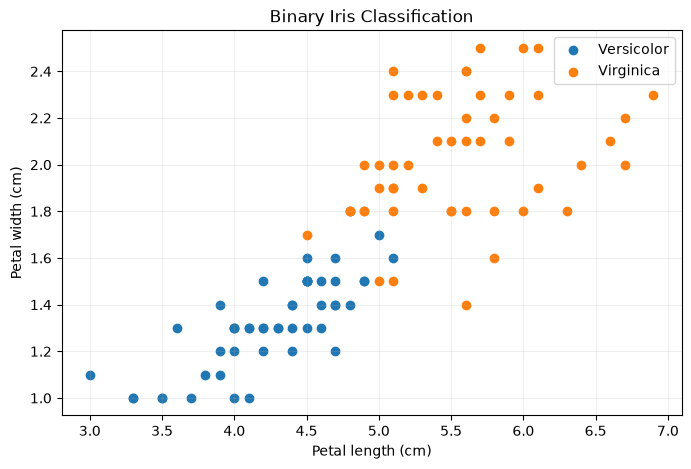

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_binary[y_binary == 0, 0],
    X_binary[y_binary == 0, 1],
    label="Versicolor"
)
plt.scatter(
    X_binary[y_binary == 1, 0],
    X_binary[y_binary == 1, 1],
    label="Virginica"
)

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Binary Iris Classification")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 3. Linear SVM classifier

A linear SVM learns a decision function:

\[
w^T x + b = 0
\]

where:

- `x` = input features
- `w` = learned weight vector
- `b` = bias/intercept

Prediction is based on which side of the boundary the point falls.

### Why maximize the margin?

Imagine many possible lines can separate the classes.

SVM prefers the line that leaves the **largest possible gap** between the two classes.

This usually gives a more robust decision boundary because small changes in the data are less likely to change the prediction.


In [17]:
linear_svm = make_pipeline(
    StandardScaler(),
    LinearSVC(C=1.0, random_state=42, max_iter=10000)
)

linear_svm.fit(X_binary, y_binary)

predictions = linear_svm.predict(X_binary)

print("Training accuracy:", np.mean(predictions == y_binary))
print("Predictions:", predictions[:20])


Training accuracy: 0.94
Predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 4. Visualize the linear SVM decision boundary

The following helper plots the decision regions.

Try changing `C` later and observe how the boundary changes.


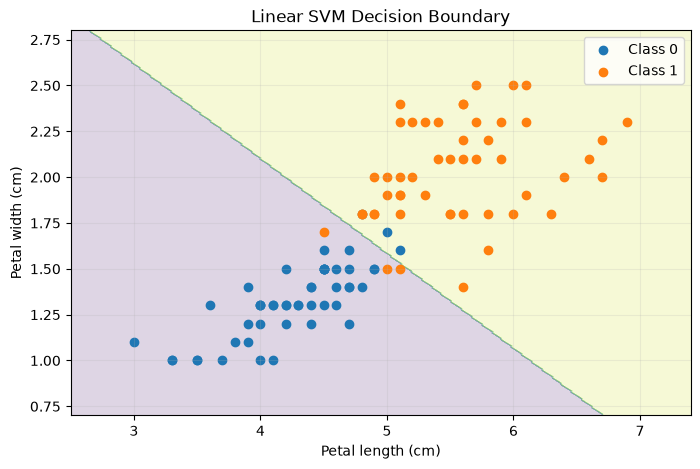

In [18]:
def plot_decision_boundary(model, X, y, title):
    x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x1_min, x1_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3

    xx0, xx1 = np.meshgrid(
        np.linspace(x0_min, x0_max, 300),
        np.linspace(x1_min, x1_max, 300)
    )

    grid = np.c_[xx0.ravel(), xx1.ravel()]
    Z = model.predict(grid).reshape(xx0.shape)

    plt.figure(figsize=(8, 5))
    plt.contourf(xx0, xx1, Z, alpha=0.18)
    plt.scatter(
        X[y == 0, 0], X[y == 0, 1],
        label="Class 0"
    )
    plt.scatter(
        X[y == 1, 0], X[y == 1, 1],
        label="Class 1"
    )

    plt.xlabel("Petal length (cm)")
    plt.ylabel("Petal width (cm)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


plot_decision_boundary(
    linear_svm,
    X_binary,
    y_binary,
    "Linear SVM Decision Boundary"
)


## 5. Hard margin vs. soft margin

### Hard margin

Hard-margin SVM tries to:

1. Separate all training examples correctly.
2. Keep all examples outside the margin.
3. Maximize the margin.

This is only practical when the data is clean and linearly separable.

### Soft margin

Real-world data often contains:

- noise
- outliers
- overlapping classes
- mislabeled examples

A soft-margin SVM allows some examples to violate the margin.

The goal becomes a trade-off:

\[
\text{large margin} + \text{few margin violations}
\]

This is where the **`C` hyperparameter** becomes important.


## 6. Understanding the `C` hyperparameter

`C` controls the penalty for classification/margin violations.

### Small `C`

A smaller `C` means:

- stronger regularization
- violations are tolerated more
- wider margin is preferred
- model can be less sensitive to individual training points

### Large `C`

A larger `C` means:

- weaker regularization
- violations are penalized strongly
- model tries harder to classify training examples correctly
- boundary can become more sensitive to individual points

### Simple intuition

Think of `C` as:

> **How much should I care about getting every training example right?**

Try:

- `C = 0.01`
- `C = 0.1`
- `C = 1`
- `C = 10`
- `C = 100`


In [19]:
C_values = [0.01, 0.1, 1, 10, 100]

for C in C_values:
    model = make_pipeline(
        StandardScaler(),
        LinearSVC(C=C, random_state=42, max_iter=10000)
    )
    model.fit(X_binary, y_binary)

    accuracy = model.score(X_binary, y_binary)
    print(f"C={C:<6} training accuracy={accuracy:.3f}")


C=0.01   training accuracy=0.940
C=0.1    training accuracy=0.940
C=1      training accuracy=0.940
C=10     training accuracy=0.940
C=100    training accuracy=0.940


## 7. Experiment: compare different `C` values visually

Run the next cell one model at a time or modify it to create your own comparison.

**Question to think about:** Does increasing `C` always improve generalization?

Answer: **No.** A higher training accuracy does not necessarily mean better performance on unseen data.


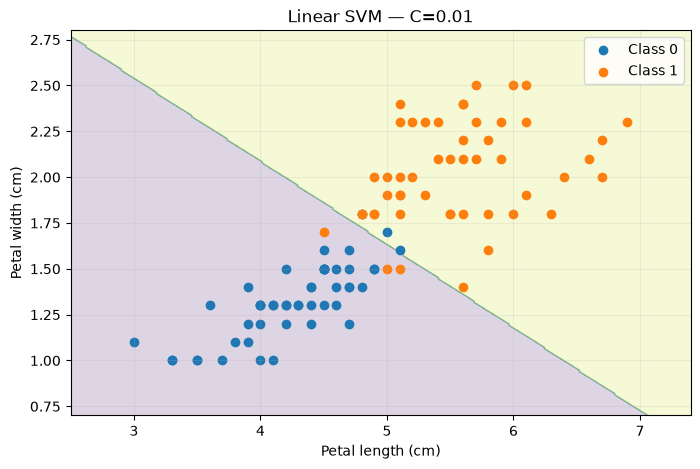

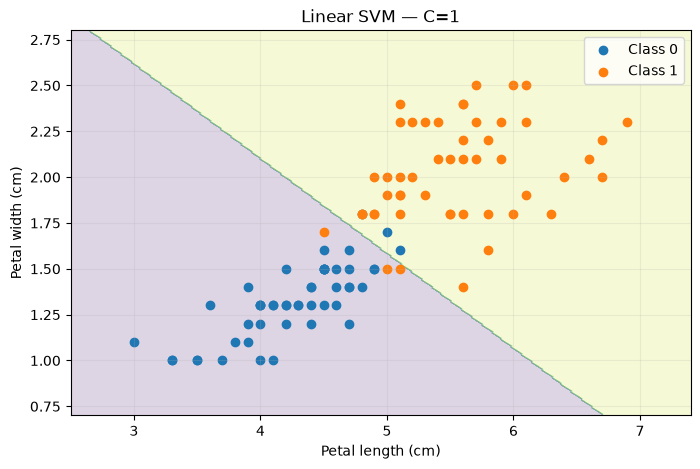

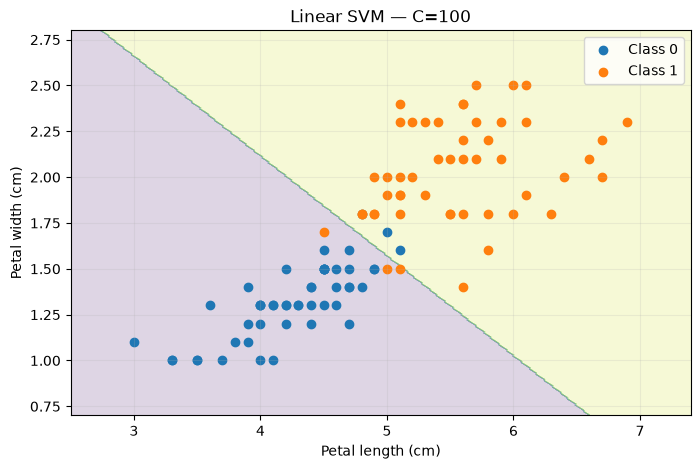

In [20]:
for C in [0.01, 1, 100]:
    model = make_pipeline(
        StandardScaler(),
        LinearSVC(C=C, random_state=42, max_iter=10000)
    )
    model.fit(X_binary, y_binary)

    plot_decision_boundary(
        model,
        X_binary,
        y_binary,
        f"Linear SVM — C={C}"
    )


# Part 2 — Nonlinear SVM Classification

A linear boundary cannot solve every classification problem.

For example, suppose one class forms a curved pattern around another class.

A straight line cannot separate them effectively.

We need a way to create a **nonlinear decision boundary**.


## 8. Polynomial features

One approach is to add polynomial features.

For example, with two features:

\[
x_1, x_2
\]

we can create additional features such as:

\[
x_1^2,\; x_1x_2,\; x_2^2
\]

The model can then learn a linear boundary in this **expanded feature space**.

When mapped back to the original feature space, that boundary can appear nonlinear.

### Important idea

> A linear model operating on transformed features can produce a nonlinear boundary in the original feature space.


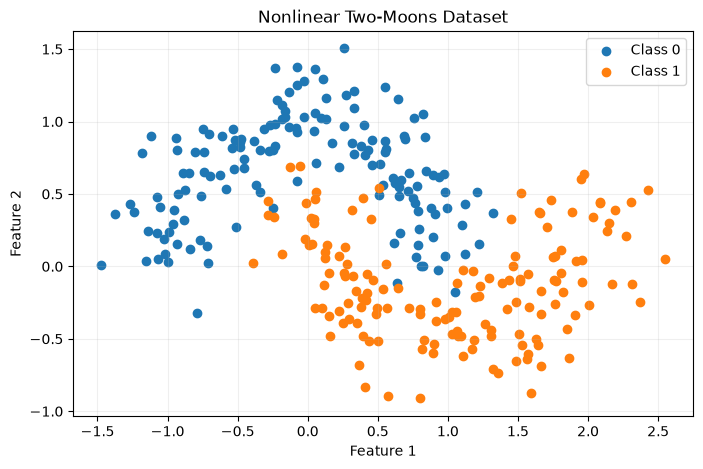

In [21]:
# Create a small nonlinear dataset
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(
    n_samples=300,
    noise=0.20,
    random_state=42
)

plt.figure(figsize=(8, 5))
plt.scatter(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1], label="Class 0")
plt.scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], label="Class 1")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Nonlinear Two-Moons Dataset")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


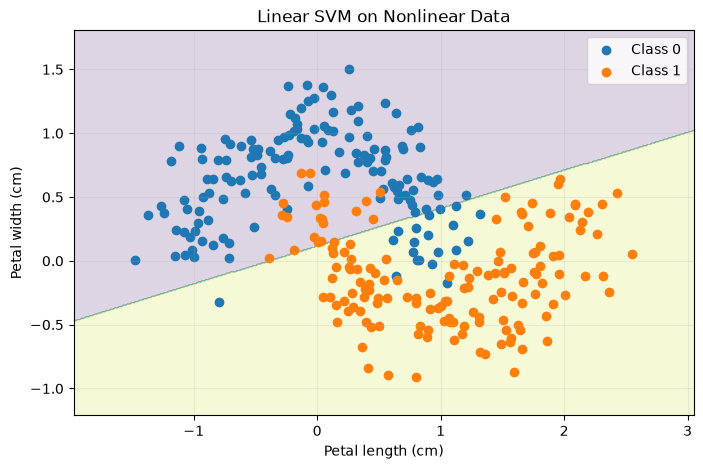

In [22]:
linear_moon_model = make_pipeline(
    StandardScaler(),
    LinearSVC(C=1.0, random_state=42, max_iter=10000)
)

linear_moon_model.fit(X_moons, y_moons)

plot_decision_boundary(
    linear_moon_model,
    X_moons,
    y_moons,
    "Linear SVM on Nonlinear Data"
)


### Try polynomial features

Now we will add polynomial features before applying a linear SVM.

The `PolynomialFeatures` transformer generates combinations such as squares and interaction terms.

Try changing `degree`:

- `degree=1` → essentially linear
- `degree=2` → quadratic features
- `degree=3` → cubic features
- higher degrees → more flexible boundaries

Be careful: very high polynomial degrees can create overfitting and many features.


Degree=2, training accuracy=0.870


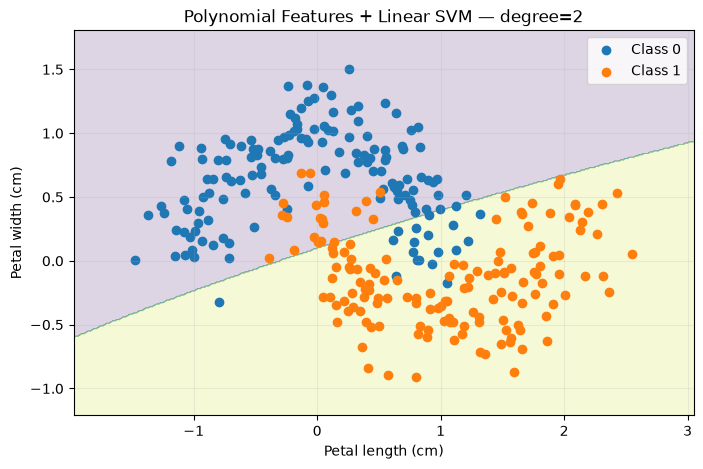

Degree=3, training accuracy=0.953


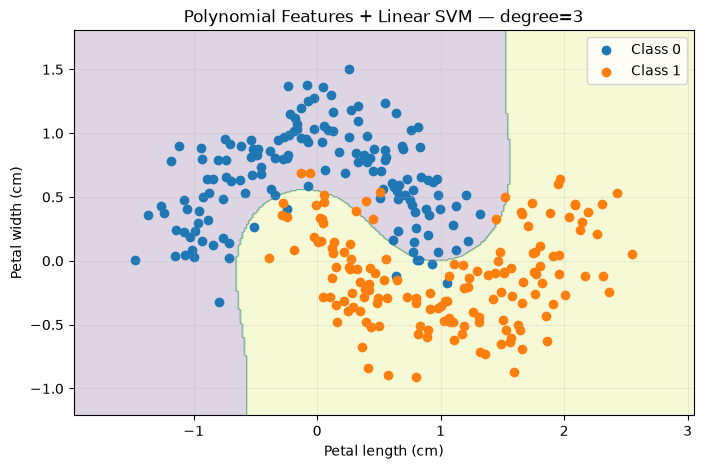

Degree=5, training accuracy=0.960


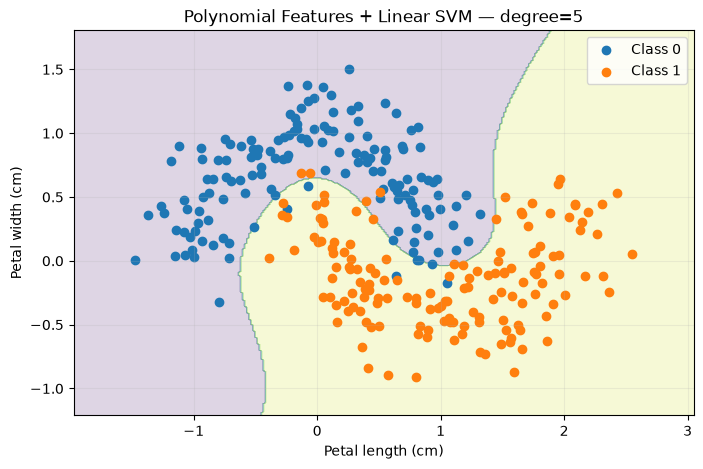

In [23]:
for degree in [2, 3, 5]:
    polynomial_model = make_pipeline(
        PolynomialFeatures(degree=degree),
        StandardScaler(),
        LinearSVC(C=1.0, random_state=42, max_iter=10000)
    )

    polynomial_model.fit(X_moons, y_moons)

    print(
        f"Degree={degree}, "
        f"training accuracy={polynomial_model.score(X_moons, y_moons):.3f}"
    )

    plot_decision_boundary(
        polynomial_model,
        X_moons,
        y_moons,
        f"Polynomial Features + Linear SVM — degree={degree}"
    )


## 9. Polynomial Kernel

There is another powerful approach: the **polynomial kernel**.

Instead of explicitly creating all polynomial features, SVM can use the **kernel trick**.

The kernel allows the algorithm to behave as though it transformed the data into a higher-dimensional feature space without explicitly constructing every feature.

For a polynomial kernel, the important hyperparameters include:

- `degree` — polynomial degree
- `C` — regularization strength
- `coef0` — controls the influence of higher- vs. lower-order terms

In Scikit-Learn:

```python
SVC(kernel="poly", degree=3, C=5, coef0=1)
```

### Kernel trick intuition

Instead of:

**transform data → create huge feature matrix → train**

we can conceptually do:

**use a kernel → compute similarities in the transformed space → train**

This can be much more efficient.


Training accuracy: 0.96


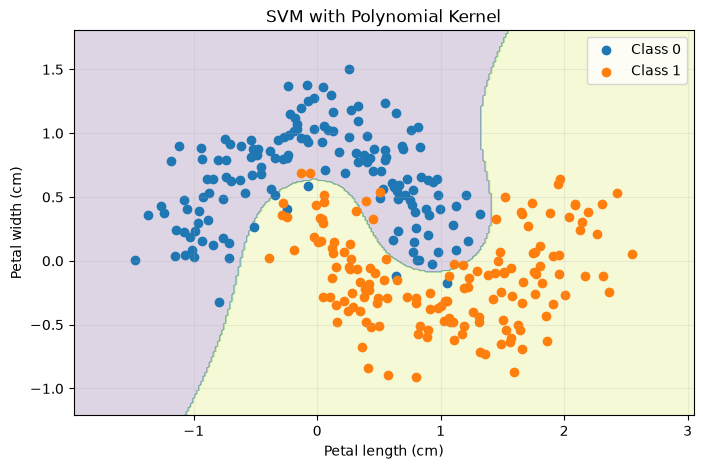

In [24]:
poly_kernel_model = make_pipeline(
    StandardScaler(),
    SVC(
        kernel="poly",
        degree=3,
        coef0=1,
        C=5
    )
)

poly_kernel_model.fit(X_moons, y_moons)

print("Training accuracy:", poly_kernel_model.score(X_moons, y_moons))

plot_decision_boundary(
    poly_kernel_model,
    X_moons,
    y_moons,
    "SVM with Polynomial Kernel"
)


## 10. Compare polynomial kernel settings

Experiment with the following:

| Parameter | Try |
|---|---|
| `degree` | 2, 3, 5 |
| `C` | 0.1, 1, 10 |
| `coef0` | 0, 1, 10 |

Think about:

1. Does increasing `degree` make the boundary more flexible?
2. What happens when `C` becomes very large?
3. Does a very flexible model necessarily generalize better?


In [25]:
experiments = [
    {"degree": 2, "C": 1, "coef0": 1},
    {"degree": 3, "C": 1, "coef0": 1},
    {"degree": 5, "C": 1, "coef0": 1},
    {"degree": 3, "C": 10, "coef0": 1},
]

for params in experiments:
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel="poly", **params)
    )

    model.fit(X_moons, y_moons)

    print(
        f"{params} -> "
        f"training accuracy={model.score(X_moons, y_moons):.3f}"
    )


{'degree': 2, 'C': 1, 'coef0': 1} -> training accuracy=0.870
{'degree': 3, 'C': 1, 'coef0': 1} -> training accuracy=0.940
{'degree': 5, 'C': 1, 'coef0': 1} -> training accuracy=0.963
{'degree': 3, 'C': 10, 'coef0': 1} -> training accuracy=0.963
